# KT In-Band Gossip Simulation — Analysis Notebook

This notebook is a **driver + analysis harness** for the Python PoC simulation of in-band gossip for Key Transparency (KT) on top of a Signal/WhatsApp-like messaging substrate.

It is designed to:
- run **single scenarios** (honest / fork / rolling equivocation)
- run **parameter sweeps** (e.g., $p_{gossip}$, adoption, fork fraction)
- parse outputs (`summary.json`, `timeline.csv`, `events.csv`)
- compute key metrics (fork detection latency, coverage, overhead)
- produce **paper-friendly plots** and **LaTeX tables**

> **Assumption:** run this notebook from your repo root (the folder that contains `sim/`, `analysis/`, `tools/`).

## 0. Environment and project discovery
We try to locate the repo root automatically and pick the correct Python executable (preferably your `.venv`).

**Windows users:** Jupyter often runs under a different Python than your `.venv`. This notebook uses `PYTHON_EXE` explicitly to call your simulator.

In [1]:

import os, sys, json, shutil, subprocess, textwrap
from pathlib import Path

# Try to locate repo root: a folder containing 'sim' and 'analysis'
HERE = Path.cwd()
candidates = [HERE] + list(HERE.parents)
REPO_ROOT = None
for p in candidates:
    if (p / "sim").exists() and (p / "analysis").exists():
        REPO_ROOT = p
        break

if REPO_ROOT is None:
    print("❗ Could not auto-detect repo root. Set REPO_ROOT manually.")
    REPO_ROOT = HERE

print("Repo root:", REPO_ROOT)

# Prefer local venv Python if present
venv_py_win = REPO_ROOT / ".venv" / "Scripts" / "python.exe"
venv_py_unix = REPO_ROOT / ".venv" / "bin" / "python"
if venv_py_win.exists():
    PYTHON_EXE = str(venv_py_win)
elif venv_py_unix.exists():
    PYTHON_EXE = str(venv_py_unix)
else:
    PYTHON_EXE = sys.executable  # fallback to current kernel python

print("Python exe:", PYTHON_EXE)

# Sanity: show version + try importing your package via subprocess
def run_cmd(cmd, cwd=REPO_ROOT):
    print(">", " ".join(cmd))
    p = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    print(p.stdout)
    if p.stderr.strip():
        print("STDERR:\n", p.stderr)
    return p.returncode

run_cmd([PYTHON_EXE, "-c", "import sys; print(sys.version)"])


Repo root: C:\Users\efasllija\dev\gossip-poc
Python exe: C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe
> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -c import sys; print(sys.version)
3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]



0

### (Optional) Install requirements
If you haven’t installed dependencies into `.venv` yet, run this once.

- If you’re on Windows and `pip` fails, run the same command in **Command Prompt**.


In [2]:

# Uncomment to install requirements
# run_cmd([PYTHON_EXE, "-m", "pip", "install", "-r", "requirements.txt"])


## 1. Define a baseline configuration
Set the baseline parameters here. These are the *experimental knobs*; your messaging substrate can be calibrated separately (survey-calibrated defaults).

**Key parameters**
- `server_mode`: honest / permanent_fork / transient_fork / rolling / freeze (depending on your implementation)
- `fork_hour`, `fork_frac`, `fork_duration`
- `p_gossip`: probability to piggyback gossip on a normal message
- `adoption`: fraction of clients that are gossip-enabled


In [5]:

BASE = dict(
    users=5_000,
    hours=6,
    dt_min=5,

    # Gossip parameters
    p_gossip=0.6,
    adoption=0.8,

    # Server behavior
    server_mode="permanent_fork",
    fork_hour=3,
    fork_frac=0.5,
    fork_duration=2,   # used if transient_fork

    # Optional adversarial knobs (only if your CLI supports them)
    p_equiv=0.0,             # rolling equivocation probability
    p_drop_crosscut=0.0,     # cross-branch drop probability

    # Optional audits (only if supported)
    # p_self_audit=0.0,
    # p_anon_check=0.0,

    # Optional: topology/traffic knobs (only if supported by your CLI)
    # avg_contacts=25,
    # groups=20_000,
    # avg_group_size=12,
    # msg_rate_1to1=0.10,
    # msg_rate_group=0.06,

    seed=42,
)
BASE


{'users': 5000,
 'hours': 6,
 'dt_min': 5,
 'p_gossip': 0.6,
 'adoption': 0.8,
 'server_mode': 'permanent_fork',
 'fork_hour': 3,
 'fork_frac': 0.5,
 'fork_duration': 2,
 'p_equiv': 0.0,
 'p_drop_crosscut': 0.0,
 'seed': 42}

## 2. Running the simulator
We call your simulator via CLI (most robust across versions):
- `python -m sim.run ...` **or** `python sim/run.py ...`

This notebook auto-detects which entrypoint works.


In [6]:

from shlex import quote

def detect_entrypoint():
    # Try module form first
    rc = subprocess.run([PYTHON_EXE, "-m", "sim.run", "--help"], cwd=REPO_ROOT,
                        capture_output=True, text=True)
    if rc.returncode == 0:
        return ["-m", "sim.run"]
    # Try file entrypoint
    run_py = REPO_ROOT / "sim" / "run.py"
    if run_py.exists():
        rc2 = subprocess.run([PYTHON_EXE, str(run_py), "--help"], cwd=REPO_ROOT,
                             capture_output=True, text=True)
        if rc2.returncode == 0:
            return [str(run_py)]
    # Fallback: fail with helpful info
    raise RuntimeError("Could not detect simulator entrypoint. "
                       "Try running `python -m sim.run --help` or check sim/run.py exists.")

ENTRY = detect_entrypoint()
print("Detected entrypoint:", ENTRY)

def params_to_args(params: dict):
    args = []
    for k, v in params.items():
        if v is None:
            continue
        flag = f"--{k}"
        if isinstance(v, bool):
            if v:
                args.append(flag)
        else:
            args.extend([flag, str(v)])
    return args

def run_sim(params: dict, outdir: str):
    outpath = Path(outdir)
    if not outpath.is_absolute():
        outpath = REPO_ROOT / outpath
    outpath.parent.mkdir(parents=True, exist_ok=True)

    p = dict(params)
    p["outdir"] = str(outpath)

    cmd = [PYTHON_EXE] + ENTRY + params_to_args(p)
    rc = run_cmd(cmd, cwd=REPO_ROOT)
    if rc != 0:
        raise RuntimeError(f"Simulation failed (rc={rc}). See stderr above.")
    return outpath

# Quick smoke test (creates/overwrites a run folder)
OUT = run_sim(BASE, outdir="out_notebook/smoke_test")
OUT


Detected entrypoint: ['-m', 'sim.run']
> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --p_gossip 0.6 --adoption 0.8 --server_mode permanent_fork --fork_hour 3 --fork_frac 0.5 --fork_duration 2 --p_equiv 0.0 --p_drop_crosscut 0.0 --seed 42 --outdir C:\Users\efasllija\dev\gossip-poc\out_notebook\smoke_test
Done. See C:\Users\efasllija\dev\gossip-poc\out_notebook\smoke_test/summary.json and C:\Users\efasllija\dev\gossip-poc\out_notebook\smoke_test/timeline.csv.



WindowsPath('C:/Users/efasllija/dev/gossip-poc/out_notebook/smoke_test')

## 3. Load outputs and compute metrics
Expected files in each run directory:
- `summary.json`
- `timeline.csv`
- `events.csv`

If your filenames differ, adjust the loader in the next cell.


In [7]:

import pandas as pd
import numpy as np

def load_run(outdir: Path):
    outdir = Path(outdir)
    summary_path = outdir / "summary.json"
    timeline_path = outdir / "timeline.csv"
    events_path = outdir / "events.csv"

    summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}
    timeline = pd.read_csv(timeline_path) if timeline_path.exists() else pd.DataFrame()
    events = pd.read_csv(events_path) if events_path.exists() else pd.DataFrame()
    return summary, timeline, events

summary, timeline, events = load_run(OUT)
summary.keys(), timeline.head(), events.head()


(dict_keys(['first_detection_tick', 'total_gossip_bytes', 'total_messages', 'proof_ok', 'proof_inconsistent', 'proof_withhold', 'proof_timeout', 'crosscut_deliveries', 'crosscut_dropped', 'users', 'hours', 'dt_min', 'p_gossip', 'mode', 'adoption', 'avg_contacts', 'groups', 'avg_group_size', 'server_mode', 'fork_hour', 'fork_frac', 'fork_duration', 'sth_period_hours', 'p_equiv', 'proof_withhold_rate', 'proof_timeout_rate', 'invalid_proof_rate', 'p_drop_crosscut', 'witness_required']),
    tick  aware_users  detectors  gossip_bytes_this_tick  proofs_ok  \
 0     0         1688          0                 1861888          0   
 1     1         2730          0                 1670144          0   
 2     2         3545          0                 2019584          0   
 3     3         4021          0                 1713152          0   
 4     4         4293          0                 1483776          0   
 
    proofs_inconsistent  proofs_withhold  proofs_timeout  crosscut_deliveries  \
 0

### Derived metrics
We compute fork detection latency relative to the fork start:
\[
t_{detect} = first\_detection\_tick \cdot \Delta t,
\quad t_{fork} = fork\_hour \cdot 60,
\quad L = \max(0, t_{detect} - t_{fork}).
\]


In [8]:

def derived_metrics(summary: dict):
    dt_min = float(summary.get("dt_min", BASE["dt_min"]))
    fork_hour = float(summary.get("fork_hour", BASE["fork_hour"]))
    first_tick = summary.get("first_detection_tick", None)

    t_fork_min = fork_hour * 60.0
    if first_tick is None or first_tick == "" or (isinstance(first_tick, float) and np.isnan(first_tick)):
        detected = False
        latency_min = np.nan
    else:
        detected = True
        t_detect_min = float(first_tick) * dt_min
        latency_min = max(0.0, t_detect_min - t_fork_min)

    users = float(summary.get("users", BASE["users"]))
    total_bytes = float(summary.get("total_gossip_bytes", np.nan))
    total_msgs = float(summary.get("total_messages", np.nan))

    return dict(
        detected=detected,
        latency_min=latency_min,
        bytes_per_user=(total_bytes / users) if np.isfinite(total_bytes) and users > 0 else np.nan,
        bytes_per_msg=(total_bytes / total_msgs) if np.isfinite(total_bytes) and total_msgs > 0 else np.nan,
        **{k: summary.get(k) for k in ["server_mode","p_gossip","adoption","fork_frac","p_equiv","p_drop_crosscut","seed","hours","dt_min","users","fork_hour"]}
    )

m = derived_metrics(summary)
m


{'detected': True,
 'latency_min': 0.0,
 'bytes_per_user': 15691.4688,
 'bytes_per_msg': 2446.669286182056,
 'server_mode': 'permanent_fork',
 'p_gossip': 0.6,
 'adoption': 0.8,
 'fork_frac': 0.5,
 'p_equiv': 0.0,
 'p_drop_crosscut': 0.0,
 'seed': None,
 'hours': 6.0,
 'dt_min': 5,
 'users': 5000,
 'fork_hour': 3.0}

## 4. Plot a single run (awareness, detectors, overhead)
These plots are useful for sanity checks.


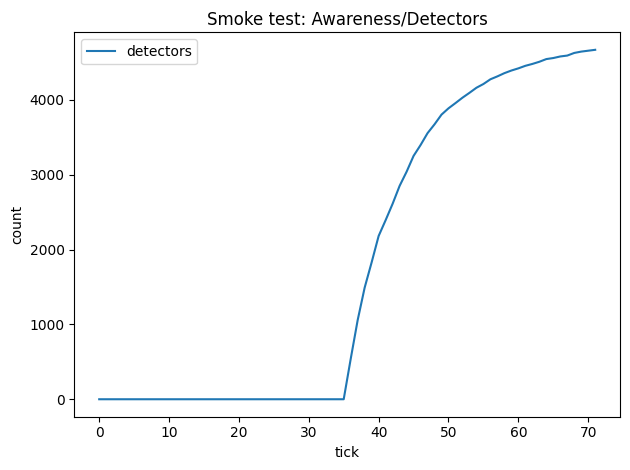

<Figure size 640x480 with 0 Axes>

In [9]:

import matplotlib.pyplot as plt

def plot_single_run(timeline: pd.DataFrame, title_prefix="Run"):
    if timeline.empty:
        print("No timeline.csv found or it is empty.")
        return

    # Common column names (adjust if your timeline differs)
    time_cols = ["tick", "t", "time", "minute"]
    tcol = next((c for c in time_cols if c in timeline.columns), None)
    if tcol is None:
        timeline = timeline.copy()
        timeline["tick"] = np.arange(len(timeline))
        tcol = "tick"

    plt.figure()
    if "aware" in timeline.columns:
        plt.plot(timeline[tcol], timeline["aware"], label="aware")
    if "detectors" in timeline.columns:
        plt.plot(timeline[tcol], timeline["detectors"], label="detectors")
    plt.xlabel(tcol)
    plt.ylabel("count")
    plt.title(f"{title_prefix}: Awareness/Detectors")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    if "gossip_bytes_cum" in timeline.columns:
        plt.plot(timeline[tcol], timeline["gossip_bytes_cum"])
        plt.ylabel("cumulative bytes")
        plt.title(f"{title_prefix}: Cumulative gossip bytes")
        plt.xlabel(tcol)
        plt.tight_layout()
        plt.show()
    elif "gossip_bytes" in timeline.columns:
        plt.plot(timeline[tcol], timeline["gossip_bytes"])
        plt.ylabel("bytes per tick")
        plt.title(f"{title_prefix}: Gossip bytes per tick")
        plt.xlabel(tcol)
        plt.tight_layout()
        plt.show()

plot_single_run(timeline, title_prefix="Smoke test")


## 5. Parameter sweeps (replicates) inside the notebook
This cell runs a small sweep over `p_gossip` and `adoption` with multiple seeds. For large sweeps, prefer your `run_sweeps.bat`, then aggregate results.

**Tip:** start small (e.g., 2k–5k users) to validate quickly.


In [10]:

from itertools import product

def sweep(pgossip_vals, adoption_vals, seeds, base=BASE, outroot="out_notebook/sweeps"):
    outroot = Path(outroot)
    results = []
    run_dirs = []

    for pg, ad, sd in product(pgossip_vals, adoption_vals, seeds):
        params = dict(base)
        params.update(p_gossip=pg, adoption=ad, seed=sd)

        name = f"pg{pg}_ad{ad}_seed{sd}".replace(".", "p")
        outdir = REPO_ROOT / outroot / name

        run_sim(params, outdir=str(outdir))
        summary, timeline, events = load_run(outdir)
        dm = derived_metrics(summary)
        dm["run_dir"] = str(outdir)
        results.append(dm)
        run_dirs.append(outdir)

    return pd.DataFrame(results), run_dirs

# Small sweep example
pgossip_vals = [0.1, 0.4, 0.8]
adoption_vals = [0.2, 0.8]
seeds = [1, 2, 3]

df_raw, run_dirs = sweep(pgossip_vals, adoption_vals, seeds)
df_raw.head(), df_raw.shape


> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --p_gossip 0.1 --adoption 0.2 --server_mode permanent_fork --fork_hour 3 --fork_frac 0.5 --fork_duration 2 --p_equiv 0.0 --p_drop_crosscut 0.0 --seed 1 --outdir C:\Users\efasllija\dev\gossip-poc\out_notebook\sweeps\pg0p1_ad0p2_seed1
Done. See C:\Users\efasllija\dev\gossip-poc\out_notebook\sweeps\pg0p1_ad0p2_seed1/summary.json and C:\Users\efasllija\dev\gossip-poc\out_notebook\sweeps\pg0p1_ad0p2_seed1/timeline.csv.

> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --p_gossip 0.1 --adoption 0.2 --server_mode permanent_fork --fork_hour 3 --fork_frac 0.5 --fork_duration 2 --p_equiv 0.0 --p_drop_crosscut 0.0 --seed 2 --outdir C:\Users\efasllija\dev\gossip-poc\out_notebook\sweeps\pg0p1_ad0p2_seed2
Done. See C:\Users\efasllija\dev\gossip-poc\out_notebook\sweeps\pg0p1_ad0p2_seed2/summary.json and C:\Users\efasllija\dev\gossip-poc\out

(   detected  latency_min  bytes_per_user  bytes_per_msg     server_mode  \
 0      True          0.0        643.3280      99.352607  permanent_fork   
 1      True          0.0        675.0464     102.781205  permanent_fork   
 2      True          0.0        602.1120      94.472652  permanent_fork   
 3      True          0.0       2598.5792     400.767921  permanent_fork   
 4      True          0.0       2562.9184     389.773763  permanent_fork   
 
    p_gossip  adoption  fork_frac  p_equiv  p_drop_crosscut  seed  hours  \
 0       0.1       0.2        0.5      0.0              0.0  None    6.0   
 1       0.1       0.2        0.5      0.0              0.0  None    6.0   
 2       0.1       0.2        0.5      0.0              0.0  None    6.0   
 3       0.1       0.8        0.5      0.0              0.0  None    6.0   
 4       0.1       0.8        0.5      0.0              0.0  None    6.0   
 
    dt_min  users  fork_hour                                            run_dir  
 0

### Aggregate sweep results (median latency, detection probability, overhead)


In [11]:

def aggregate(df_raw: pd.DataFrame):
    g = df_raw.groupby(["server_mode","p_gossip","adoption","fork_frac"], dropna=False)
    out = g.agg(
        reps=("seed","count"),
        det_rate=("detected","mean"),
        lat_med=("latency_min","median"),
        lat_mean=("latency_min","mean"),
        bpu_mean=("bytes_per_user","mean"),
        bpm_mean=("bytes_per_msg","mean"),
    ).reset_index()
    return out

df_agg = aggregate(df_raw)
df_agg


,server_mode,p_gossip,adoption,fork_frac,reps,det_rate,lat_med,lat_mean,bpu_mean,bpm_mean
0,permanent_fork,0.1,0.2,0.5,0,1.0,0.0,0.0,640.162133,98.868821
1,permanent_fork,0.1,0.8,0.5,0,1.0,0.0,0.0,2549.597867,392.870569
2,permanent_fork,0.4,0.2,0.5,0,1.0,0.0,0.0,2580.599467,398.662622
3,permanent_fork,0.4,0.8,0.5,0,1.0,0.0,0.0,10216.192000,1574.113603
4,permanent_fork,0.8,0.2,0.5,0,1.0,0.0,0.0,5133.064533,793.171156
5,permanent_fork,0.8,0.8,0.5,0,1.0,0.0,0.0,20529.450667,3163.328342


### Plot: detection latency vs $p_{gossip}$ (by adoption)


C:\Users\efasllija\AppData\Local\Temp\ipykernel_56088\2566469819.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


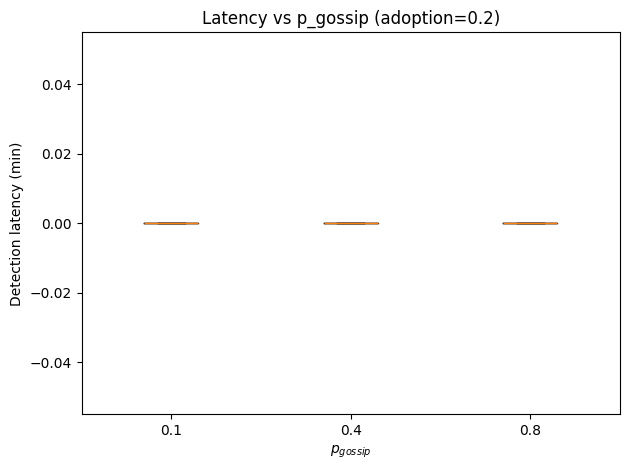

C:\Users\efasllija\AppData\Local\Temp\ipykernel_56088\2566469819.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


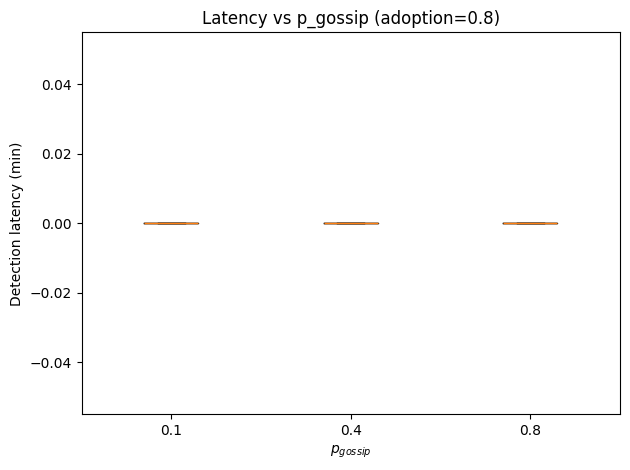

In [12]:

def boxplot_latency(df_raw: pd.DataFrame):
    import matplotlib.pyplot as plt
    df = df_raw.copy()
    df = df[df["detected"] == True]

    for ad in sorted(df["adoption"].dropna().unique()):
        sub = df[df["adoption"] == ad]
        groups = []
        labels = []
        for pg in sorted(sub["p_gossip"].dropna().unique()):
            vals = sub[sub["p_gossip"] == pg]["latency_min"].dropna().values
            if len(vals) > 0:
                groups.append(vals)
                labels.append(str(pg))

        plt.figure()
        plt.boxplot(groups, labels=labels, showfliers=False)
        plt.xlabel(r"$p_{gossip}$")
        plt.ylabel("Detection latency (min)")
        plt.title(f"Latency vs p_gossip (adoption={ad})")
        plt.tight_layout()
        plt.show()

boxplot_latency(df_raw)


## 6. Export a LaTeX table (booktabs)
This generates a compact LaTeX table from the aggregated results.


In [ ]:

def to_latex_booktabs(df: pd.DataFrame, path: str, caption="Results", label="tab:results"):
    latex = df.to_latex(index=False, escape=False, float_format="%.3g")
    # Wrap with caption/label for convenience (optional)
    table = "\\begin{table}[t]\n\\centering\n\\small\n"
    table += f"\\caption{{{caption}}}\n\\label{{{label}}}\n"
    table += latex
    table += "\\end{table}\n"
    Path(path).write_text(table, encoding="utf-8")
    print("Wrote:", path)

# Choose columns to keep it USENIX-tight
tbl = df_agg[["p_gossip","adoption","reps","det_rate","lat_med","bpu_mean"]].copy()
tbl = tbl.rename(columns=dict(det_rate="Detect", lat_med="MedLat(min)", bpu_mean="Bytes/user"))
to_latex_booktabs(tbl, "out_notebook/results_table.tex",
                  caption="Sweep summary (median latency, detection rate, overhead).",
                  label="tab:sweep_summary")
tbl


## 7. Next steps (recommended workflow)
For paper-scale sweeps (many points × many seeds), run your batch runner (e.g., `run_sweeps.bat`) and then:
1) aggregate all `summary.json` into `all_summaries_raw.csv` and `all_summaries_agg.csv`
2) generate USENIX figures: boxplots, heatmaps, tradeoff scatter
3) export LaTeX tables (`booktabs`) for Evaluation.

This notebook is ideal for:
- sanity checks on new scenarios
- small ablations
- quickly producing a plot/table without leaving Jupyter.


In [ ]:
from itertools import product
from pathlib import Path
import pandas as pd
import numpy as np
import json, time
SWEEP_ROOT = REPO_ROOT / "out_sweeps_nb"   # keep notebook sweeps separate
SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
# Minimal baseline that is likely supported by your CLI
BASE = dict(
   users=5000,
   hours=6,
   dt_min=5,
   server_mode="permanent_fork",  # adjust if your CLI uses a different name
   fork_hour=3,
   fork_frac=0.5,
   seed=42,
   p_gossip=0.6,
   adoption=0.8,
)
# Sweep space (edit as needed)
SWEEP = dict(
   p_gossip=[0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
   adoption=[0.2, 0.4, 0.6, 0.8, 1.0],
   fork_frac=[0.1, 0.2, 0.5],  # optional slice; reduce if too big
)
REPLICATES = 5
SEED_BASE = 1000
print("Sweep root:", SWEEP_ROOT)
print("Total configs (without reps):",
     len(SWEEP["p_gossip"]) * len(SWEEP["adoption"]) * len(SWEEP["fork_frac"]))
print("Total runs (with reps):",
     len(SWEEP["p_gossip"]) * len(SWEEP["adoption"]) * len(SWEEP["fork_frac"]) * REPLICATES)

In [ ]:
import subprocess
from datetime import datetime
def run_sim_to_outdir(params: dict, outdir: Path):
   outdir = Path(outdir)
   outdir.mkdir(parents=True, exist_ok=True)
   p = dict(params)
   p["outdir"] = str(outdir)
   cmd = [PYTHON_EXE] + ENTRY + params_to_args(p)
   rc = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
   if rc.returncode != 0:
       print("FAILED:", outdir)
       print("STDOUT:\n", rc.stdout)
       print("STDERR:\n", rc.stderr)
       raise RuntimeError(f"Simulation failed rc={rc.returncode}")
   return outdir
def outdir_name(cfg: dict, seed: int):
   # stable + filename-safe
   def fmt(v):
       if isinstance(v, float):
           s = f"{v:g}".replace(".", "p")
           return s
       return str(v)
   parts = [
       f"mode_{cfg.get('server_mode','')}",
       f"pg_{fmt(cfg['p_gossip'])}",
       f"a_{fmt(cfg['adoption'])}",
       f"f_{fmt(cfg['fork_frac'])}",
       f"seed_{seed}",
   ]
   return "__".join(parts)
def has_outputs(outdir: Path):
   # adjust filenames if your sim writes differently
   return (outdir / "summary.json").exists()
def run_sweep(base: dict, sweep: dict, replicates: int, seed_base: int, outroot: Path):
   outroot = Path(outroot)
   results = []
   started = 0
   skipped = 0
   grid_keys = list(sweep.keys())
   for values in product(*[sweep[k] for k in grid_keys]):
       cfg = dict(base)
       for k, v in zip(grid_keys, values):
           cfg[k] = v
       for r in range(replicates):
           seed = seed_base + r
           cfg_run = dict(cfg)
           cfg_run["seed"] = seed
           od = outroot / outdir_name(cfg_run, seed)
           if has_outputs(od):
               skipped += 1
               # still collect metrics so tables/plots work
               summary, timeline, events = load_run(od)
               dm = derived_metrics(summary)
               dm["run_dir"] = str(od)
               results.append(dm)
               continue
           started += 1
           run_sim_to_outdir(cfg_run, od)
           summary, timeline, events = load_run(od)
           dm = derived_metrics(summary)
           dm["run_dir"] = str(od)
           results.append(dm)
           if started % 10 == 0:
               print(f"[{datetime.now().strftime('%H:%M:%S')}] started={started}, skipped={skipped}")
   df_raw = pd.DataFrame(results)
   print("Done. started=", started, "skipped=", skipped, "rows=", len(df_raw))
   return df_raw
df_raw = run_sweep(BASE, SWEEP, REPLICATES, SEED_BASE, SWEEP_ROOT)
df_raw.head()